In [19]:
import pandas as pd
import numpy as np
import matplotlib as plot

In [20]:
df = pd.read_csv("/workspaces/E-Commerce-Customer-Intelligence-Platform-using-Machine-Learning-and-MLOps/data/Dataset by Olist.csv")

In [21]:
# Check shape and columns
print("Shape:", df.shape)
print(df.columns)

Shape: (113390, 39)
Index(['Unnamed: 0', 'order_id', 'order_item_id', 'customer_id',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'product_id', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_id', 'seller_city',
       'seller_state', 'seller_zip_code_prefix', 'payment_type',
       'payment_sequential', 'payment_installments', 'price', 'freight_value',
       'payment_value', 'shipping_limit_date', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'day_of_purchase', 'month_of_purchase', 'year_of_purchase',
       'month/year_of_purchase', 'order_status', 'order_unique_id'],
      dtype='str')


In [22]:
df.head()

,Unnamed: 0,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1
4,4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,...,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01 00:00:00,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1


In [23]:
# Drop unnecessary index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Check first rows
df.head()

,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,product_name_lenght,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26 00:00:00,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07 00:00:00,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25 00:00:00,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1
4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01 00:00:00,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1


In [24]:
df.isnull().sum()

order_id                         0
order_item_id                    0
customer_id                      0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_id                       0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
seller_id                        0
seller_city                      0
seller_state                     0
seller_zip_code_prefix           0
payment_type                     0
payment_sequential               0
payment_installments             0
price                            0
freight_value                    0
payment_value                    0
shipping_limit_date              0
order_purchase_timestamp         0
order_approved_at   

In [25]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_report.head(20)

,missing_count,missing_percent
order_id,0,0.0
order_item_id,0,0.0
customer_id,0,0.0
customer_unique_id,0,0.0
customer_zip_code_prefix,0,0.0
customer_city,0,0.0
customer_state,0,0.0
product_id,0,0.0
product_category_name,0,0.0
product_name_lenght,0,0.0


In [26]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [27]:
df.head(5)

,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,product_name_lenght,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,day_of_purchase,month_of_purchase,year_of_purchase,month/year_of_purchase,order_status,order_unique_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,Wednesday,September,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1
1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017-06-29 02:44:11,2017-07-05 12:00:33,2017-07-13 20:39:29,2017-07-26,Wednesday,June,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1
2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2018-05-18 12:31:43,2018-05-23 14:05:00,2018-06-04 18:34:26,2018-06-07,Friday,May,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1
3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017-08-01 18:55:08,2017-08-02 19:07:36,2017-08-09 21:26:33,2017-08-25,Tuesday,August,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1
4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017-08-10 22:05:11,2017-08-11 19:43:07,2017-08-24 20:04:21,2017-09-01,Thursday,August,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1


In [28]:
df = df[df["order_status"] == "delivered"].copy()

df = df.dropna(subset=[
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

print(df.shape)

(113383, 38)


In [29]:
df["delivery_delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

df["delivery_delay_flag"] = np.where(df["delivery_delay_days"] > 0, 1, 0)

df["delivery_delay_flag"].value_counts(normalize=True)

delivery_delay_flag
0    0.934673
1    0.065327
Name: proportion, dtype: float64

In [30]:
df["purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek
df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_year"] = df["order_purchase_timestamp"].dt.year

df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
).dt.days

df["product_volume"] = (
    df["product_length_cm"] * df["product_height_cm"] * df["product_width_cm"]
) if all(col in df.columns for col in ["product_length_cm", "product_height_cm", "product_width_cm"]) else np.nan

In [31]:
features = [
    "customer_state",
    "customer_city",
    "product_category_name",
    "payment_type",
    "payment_value",
    "freight_value",
    "price",
    "product_weight_g",
    "product_volume",
    "purchase_dayofweek",
    "purchase_month",
    "purchase_year",
    "estimated_delivery_days"
]

# Keep only columns available in your CSV
features = [col for col in features if col in df.columns]

X = df[features]
y = df["delivery_delay_flag"]

print(X.shape)
print(y.value_counts())

(113383, 13)
delivery_delay_flag
0    105976
1      7407
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [50]:
# Logistic Regression
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
#categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])



### Old code
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report Logistics Regression:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

In [51]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["order_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [52]:
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Classification Report Logistics Regression:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

Classification Report Logistics Regression:
              precision    recall  f1-score   support

           0       0.96      0.68      0.80     21203
           1       0.12      0.61      0.20      1501

    accuracy                           0.67     22704
   macro avg       0.54      0.64      0.50     22704
weighted avg       0.90      0.67      0.76     22704

Confusion Matrix:
[[14408  6795]
 [  592   909]]
ROC AUC: 0.6788288384391697


In [53]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Report:")
print(classification_report(y_test, rf_pred))

print("ROC AUC:", roc_auc_score(y_test, rf_prob))

Random Forest Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     21203
           1       0.37      0.02      0.04      1501

    accuracy                           0.93     22704
   macro avg       0.65      0.51      0.50     22704
weighted avg       0.90      0.93      0.90     22704

ROC AUC: 0.6852227270517796


In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    rf_pred_threshold = (rf_prob >= threshold).astype(int)

    precision = precision_score(y_test, rf_pred_threshold)
    recall = recall_score(y_test, rf_pred_threshold)
    f1 = f1_score(y_test, rf_pred_threshold)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print("-" * 30)

Threshold: 0.3
Precision: 0.281
Recall: 0.076
F1 Score: 0.120
------------------------------
Threshold: 0.4
Precision: 0.328
Recall: 0.039
F1 Score: 0.070
------------------------------
Threshold: 0.5
Precision: 0.366
Recall: 0.023
F1 Score: 0.043
------------------------------
Threshold: 0.6
Precision: 0.396
Recall: 0.013
F1 Score: 0.025
------------------------------
Threshold: 0.7
Precision: 0.500
Recall: 0.005
F1 Score: 0.011
------------------------------


In [56]:
from sklearn.metrics import average_precision_score

log_pr_auc = average_precision_score(y_test, y_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)

print("Logistic Regression PR-AUC:", log_pr_auc)
print("Random Forest PR-AUC:", rf_pr_auc)

Logistic Regression PR-AUC: 0.13141654343914935
Random Forest PR-AUC: 0.1491716129481307


In [57]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

os.makedirs("reports/figures", exist_ok=True)

In [59]:
type(model)

sklearn.pipeline.Pipeline

In [60]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model
}

results = []

for model_name, model_obj in models.items():
    y_pred = model_obj.predict(X_test)
    y_prob = model_obj.predict_proba(X_test)[:, 1]

    results.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        "precision_delay": precision_score(y_test, y_pred),
        "recall_delay": recall_score(y_test, y_pred),
        "f1_delay": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,model,roc_auc,pr_auc,precision_delay,recall_delay,f1_delay
0,Logistic Regression,0.678829,0.131417,0.117991,0.605596,0.197501
1,Random Forest,0.685223,0.149172,0.366667,0.021985,0.041483


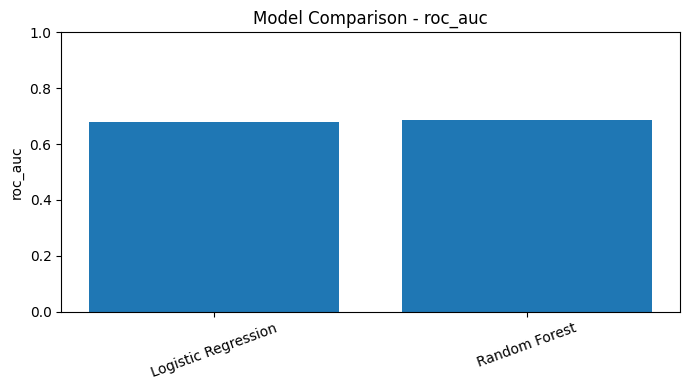

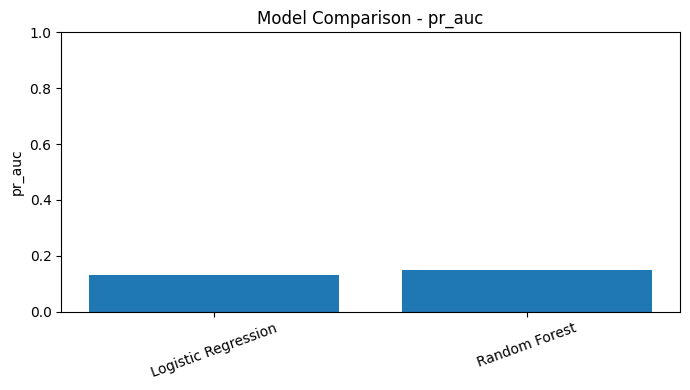

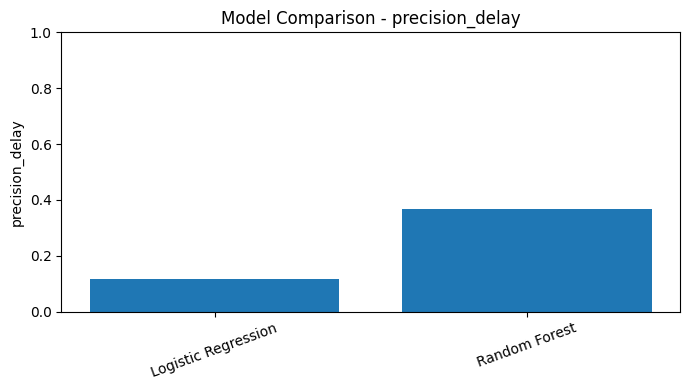

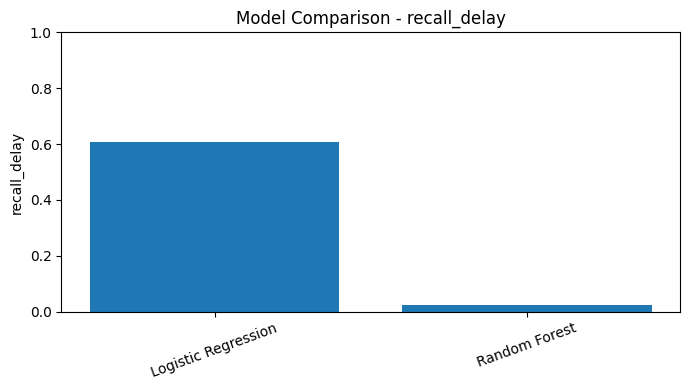

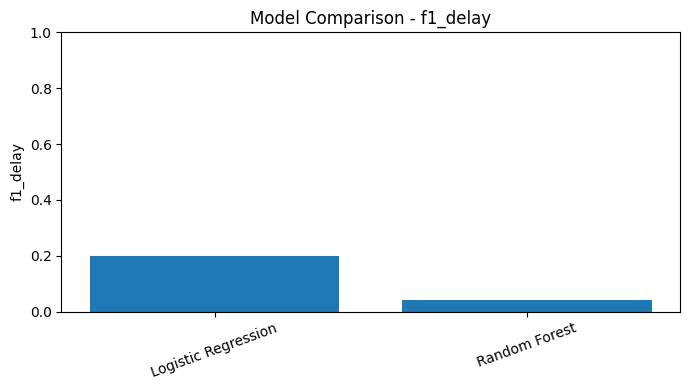

In [61]:
# For Model comaparision chart
metrics = ["roc_auc", "pr_auc", "precision_delay", "recall_delay", "f1_delay"]

for metric in metrics:
    plt.figure(figsize=(7, 4))
    plt.bar(results_df["model"], results_df[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f"reports/figures/model_comparison_{metric}.png", dpi=300)
    plt.show()

<Figure size 600x500 with 0 Axes>

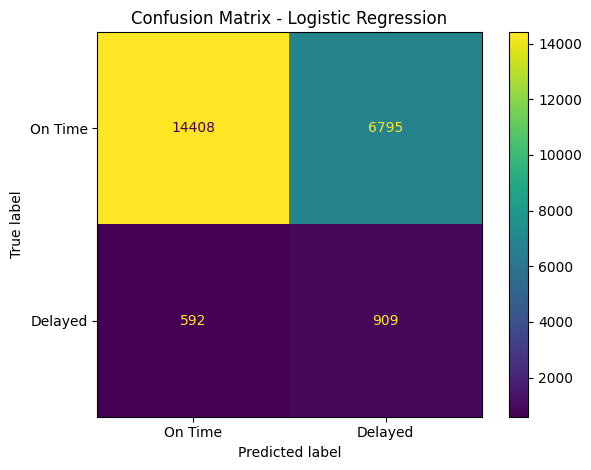

<Figure size 600x500 with 0 Axes>

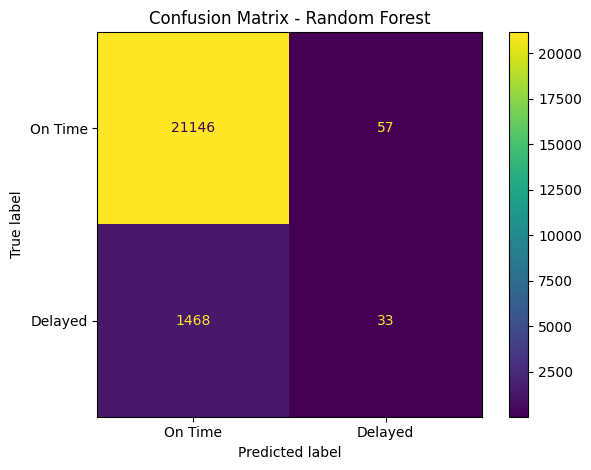

In [63]:
# Confusion matrix visualization
for model_name, model in models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["On Time", "Delayed"]
    )

    plt.figure(figsize=(6, 5))
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.savefig(f"reports/figures/confusion_matrix_{model_name.replace(' ', '_')}.png", dpi=300)
    plt.show()

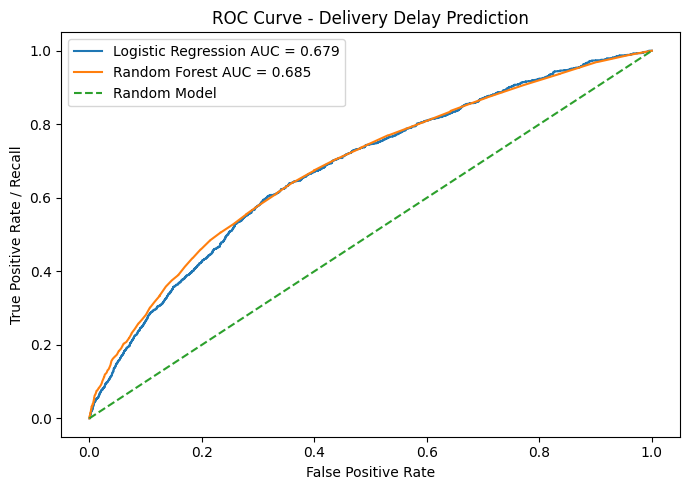

In [64]:
#ROC Curve
plt.figure(figsize=(7, 5))

for model_name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{model_name} AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.title("ROC Curve - Delivery Delay Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/roc_curve.png", dpi=300)
plt.show()

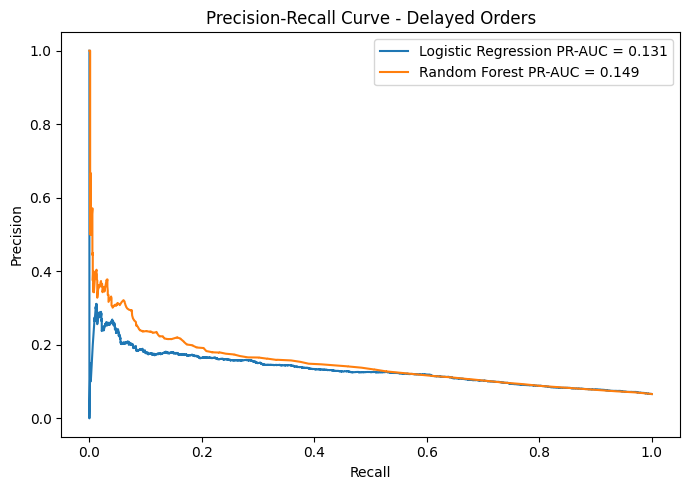

In [65]:
#Precision- Recall curve
plt.figure(figsize=(7, 5))

for model_name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, label=f"{model_name} PR-AUC = {pr_auc:.3f}")

plt.title("Precision-Recall Curve - Delayed Orders")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/precision_recall_curve.png", dpi=300)
plt.show()

In [66]:
# Threshold tunning visualization
thresholds = np.arange(0.1, 0.9, 0.05)

threshold_results = []

for model_name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    for threshold in thresholds:
        y_pred_threshold = (y_prob >= threshold).astype(int)

        threshold_results.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
            "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
        })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.head()

,model,threshold,precision,recall,f1
0,Logistic Regression,0.10,0.069417,0.982012,0.129668
1,Logistic Regression,0.15,0.071927,0.960693,0.133835
2,Logistic Regression,0.20,0.074800,0.930047,0.138465
3,Logistic Regression,0.25,0.078718,0.896736,0.144731
4,Logistic Regression,0.30,0.083110,0.846769,0.151364


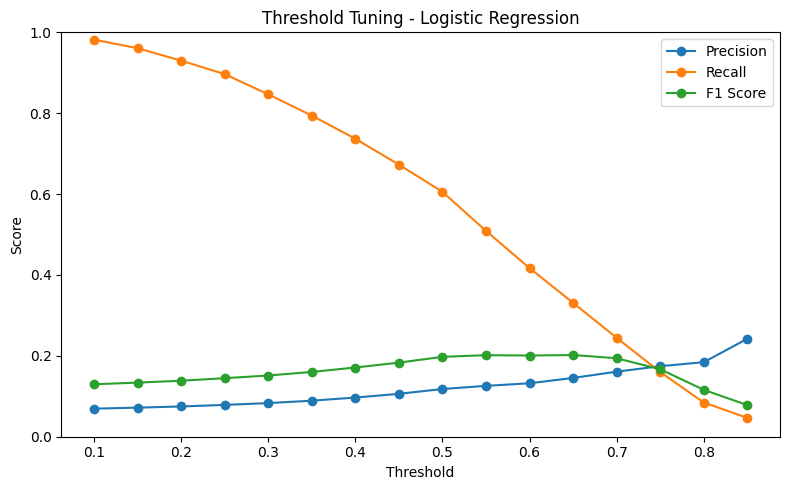

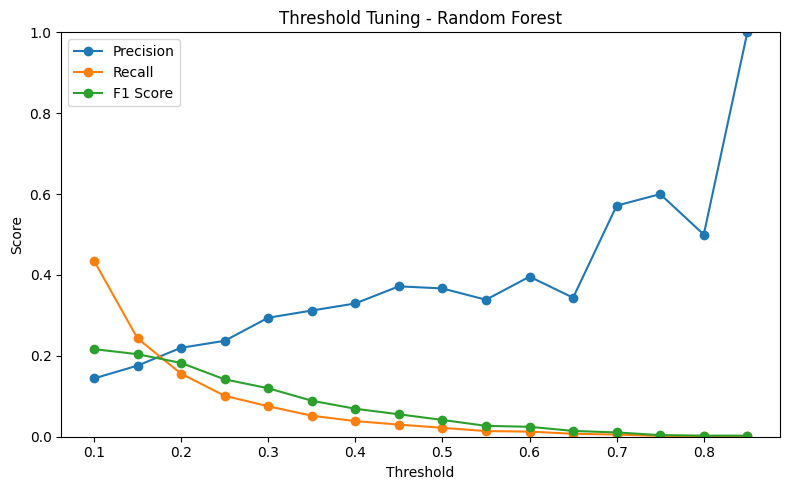

In [67]:
for model_name in threshold_df["model"].unique():
    temp = threshold_df[threshold_df["model"] == model_name]

    plt.figure(figsize=(8, 5))
    plt.plot(temp["threshold"], temp["precision"], marker="o", label="Precision")
    plt.plot(temp["threshold"], temp["recall"], marker="o", label="Recall")
    plt.plot(temp["threshold"], temp["f1"], marker="o", label="F1 Score")

    plt.title(f"Threshold Tuning - {model_name}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"reports/figures/threshold_tuning_{model_name.replace(' ', '_')}.png", dpi=300)
    plt.show()

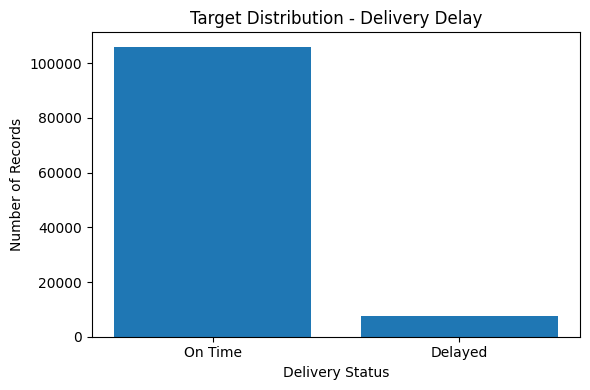

delivery_delay_flag
0    93.467275
1     6.532725
Name: proportion, dtype: float64


In [68]:
#Target distribution visualization
target_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["On Time", "Delayed"], target_counts.values)
plt.title("Target Distribution - Delivery Delay")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig("reports/figures/target_distribution.png", dpi=300)
plt.show()

print(y.value_counts(normalize=True) * 100)

In [69]:
#Feature importance for Random Forest
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
5,num__estimated_delivery_days,0.108716
1,num__freight_value,0.096293
0,num__payment_value,0.094790
2,num__price,0.090253
4,num__product_volume,0.086780
3,num__product_weight_g,0.085308
31,cat__customer_state_SP,0.012192
24,cat__customer_state_RJ,0.011589
3920,cat__payment_type_credit_card,0.009901
3919,cat__payment_type_boleto,0.009269


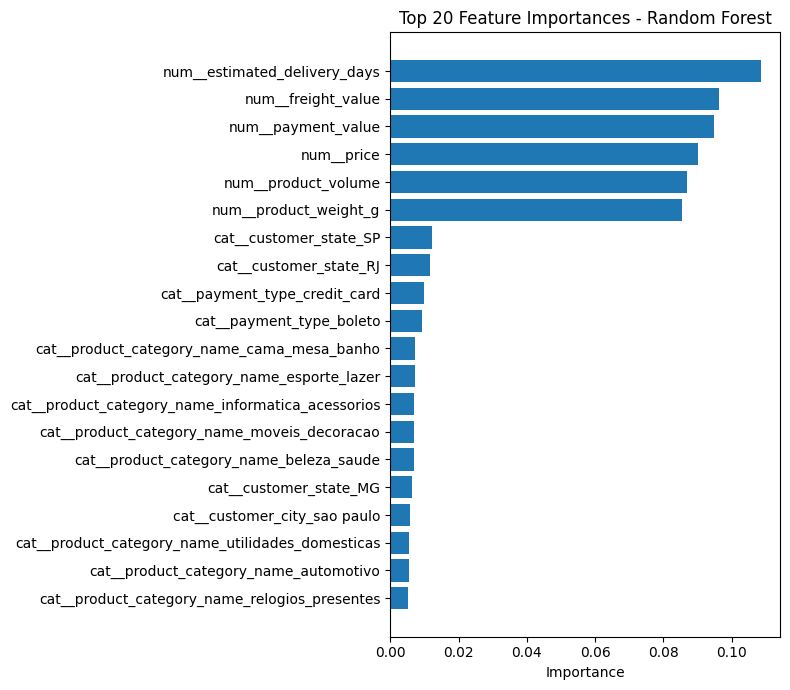

In [70]:
top_features = feature_importance_df.head(20).sort_values(by="importance")

plt.figure(figsize=(8, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("reports/figures/random_forest_feature_importance.png", dpi=300)
plt.show()